# CO5085 - Part 4 Notebook  
## Các kiến trúc kết hợp và các cách embed ảnh khác nhau (Colab-ready)

Notebook này được thiết kế để **phục vụ trực tiếp cho Phần 4** của đề bài:
- triển khai **nhiều kiến trúc khác nhau** trên **cùng một tập dữ liệu**,
- **tự viết training loop** bằng PyTorch,
- **huấn luyện, đánh giá, so sánh** bằng bảng số liệu + biểu đồ,
- tạo sẵn **figure / chart / visualization** để chèn vào báo cáo.

> Phạm vi của notebook: **Part 4** (không bao gồm Part 1/2/3/5 của toàn bộ assignment).  
> Tuy nhiên, code được tổ chức sạch để nhóm có thể tái sử dụng utility cho các phần khác nếu cần.

## 0. Check alignment với đề và rubric

### Yêu cầu cốt lõi của Part 4
Theo đề bài, Phần 4 yêu cầu:
1. Xây dựng **ít nhất hai hoặc ba** cách kiến trúc khác nhau theo các hướng như:
   - **CNN + Transformer**
   - **các kiểu tokenizer / image embedding khác nhau**
   - **Transformer với token theo chiều không gian HxW hoặc theo chiều kênh C**
2. **Huấn luyện, đánh giá, so sánh**
3. Trình bày kết quả bằng:
   - **bảng số liệu**
   - **biểu đồ**
   - **nhận xét rõ ràng**

### Cách notebook này đáp ứng yêu cầu
Notebook này triển khai **4 mô hình** (vượt mức tối thiểu 2-3 mô hình):
1. **Hybrid CNN -> Transformer (Spatial Tokens)**  
   CNN backbone trích xuất feature map, sau đó mỗi vị trí không gian là một token.
2. **ViT với patch embedding không overlap**  
   Ảnh được chia patch 4x4, stride = 4.
3. **ViT với patch embedding có overlap**  
   Ảnh được chia patch 4x4, stride = 2.
4. **Hybrid CNN -> Transformer (Channel Tokens)**  
   CNN backbone trích xuất feature map, sau đó mỗi kênh là một token.

### Enhance thêm so với mức tối thiểu
Ngoài phần bắt buộc, notebook còn có:
- visualize dữ liệu đầu vào,
- visualize patch/tokenization,
- chart loss/accuracy theo epoch,
- confusion matrix,
- sample predictions đúng/sai,
- bảng so sánh accuracy / params / thời gian train,
- lưu figure ra thư mục riêng để chèn vào báo cáo.

> Tập dữ liệu mặc định: **CIFAR-10** vì phù hợp nhất cho việc so sánh patch embedding, overlap và mô hình lai CNN-Transformer.

In [35]:
# Nếu đang chạy trên Colab, cell này sẽ in thông tin runtime và kiểm tra GPU.
import os
import sys
import platform
import torch

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Khuyến nghị: bật GPU trong Colab (Runtime -> Change runtime type -> GPU)")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [33]:
# Imports chính
import os
import time
import math
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from IPython.display import display

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

## 1. Cấu hình chung

- Dataset mặc định: **CIFAR-10**
- Mục tiêu: cân bằng giữa **độ đầy đủ của thực nghiệm** và **runtime phù hợp với Colab**
- Bạn có thể tăng `EPOCHS` nếu muốn số đẹp hơn cho báo cáo cuối cùng

In [5]:
# =========================
# CONFIG
# =========================
SEED = 13
DATA_ROOT = "./data"
OUTPUT_DIR = Path("./outputs_part4")
FIG_DIR = OUTPUT_DIR / "figures"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
TABLE_DIR = OUTPUT_DIR / "tables"

for p in [OUTPUT_DIR, FIG_DIR, CKPT_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2 if os.cpu_count() and os.cpu_count() > 2 else 0
PIN_MEMORY = DEVICE.type == "cuda"

# Default final-run config
BATCH_SIZE = 128
EPOCHS = 12           # có thể tăng lên 15-20 cho báo cáo cuối cùng
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Nếu muốn debug nhanh hơn trên Colab, bật FAST_MODE = True
FAST_MODE = False
FAST_TRAIN_SAMPLES = 12000
FAST_VAL_SAMPLES = 2000
FAST_TEST_SAMPLES = 3000

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("DEVICE:", DEVICE)
print("NUM_WORKERS:", NUM_WORKERS)
print("FAST_MODE:", FAST_MODE)
print("Outputs will be saved to:", OUTPUT_DIR.resolve())

DEVICE: cuda
NUM_WORKERS: 0
FAST_MODE: False
Outputs will be saved to: /content/outputs_part4


## 2. Dataset và DataLoader

### Vì sao chọn CIFAR-10?
CIFAR-10 phù hợp nhất cho Part 4 vì:
- ảnh màu 32x32 giàu thông tin hơn MNIST / Fashion-MNIST,
- phù hợp để so sánh **patch embedding**, **overlap patch**, **CNN backbone + Transformer**,
- vẫn đủ nhỏ để chạy được trên Colab.

Notebook chia dữ liệu thành:
- **train**
- **validation**
- **test**

Validation set được tách từ train set theo cách **stratified split** để phân bố lớp ổn định.

In [6]:
# =========================
# DATASET
# =========================
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Load once without transform to get labels for stratified split
base_train = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=True)
test_dataset = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=eval_transform)

all_indices = np.arange(len(base_train))
all_targets = np.array(base_train.targets)

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=5000,
    random_state=SEED,
    stratify=all_targets
)

train_dataset_full = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=False, transform=train_transform)
val_dataset_full = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=False, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

if FAST_MODE:
    train_dataset = Subset(train_dataset, list(range(min(FAST_TRAIN_SAMPLES, len(train_dataset)))))
    val_dataset = Subset(val_dataset, list(range(min(FAST_VAL_SAMPLES, len(val_dataset)))))
    test_dataset = Subset(test_dataset, list(range(min(FAST_TEST_SAMPLES, len(test_dataset)))))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

classes = base_train.classes
print("Classes:", classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [00:04<00:00, 40.2MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 45000
Val size: 5000
Test size: 10000


In [7]:
# Helper để bỏ normalize khi visualize
def denormalize_img(img_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return torch.clamp(img, 0, 1)

def save_figure(fig, filename, dpi=180):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure -> {path}")

## 3. Visualize dữ liệu đầu vào

Các figure ở phần này có thể dùng trực tiếp cho báo cáo:
- ảnh mẫu theo lớp,
- phân bố số lượng ảnh mỗi lớp,
- ví dụ augmentation.

,class_id,class_name,count
0,0,airplane,4500
1,1,automobile,4500
2,2,bird,4500
3,3,cat,4500
4,4,deer,4500
5,5,dog,4500
6,6,frog,4500
7,7,horse,4500
8,8,ship,4500
9,9,truck,4500


Saved figure -> outputs_part4/figures/01_class_distribution_magma.png


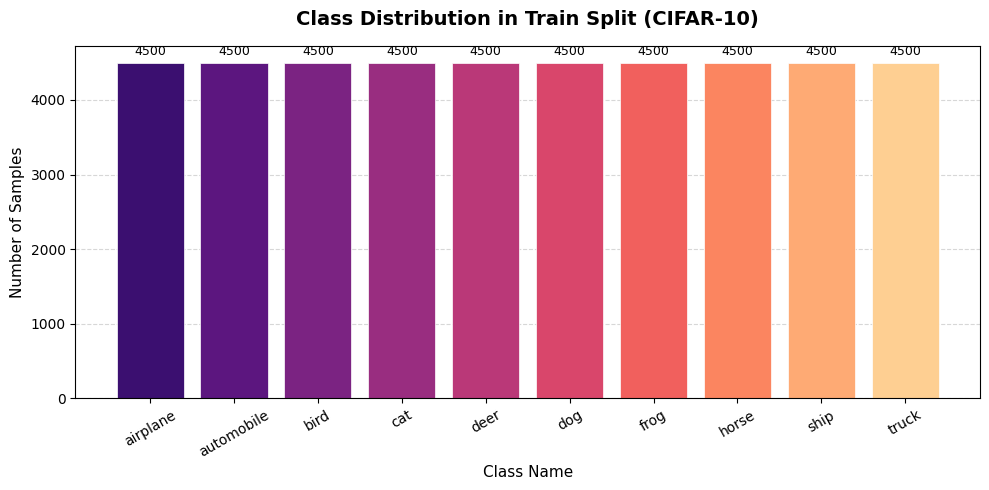

In [27]:
# Figure 1: số lượng mẫu mỗi lớp trong train split
train_targets = all_targets[train_idx]
class_counts = pd.Series(train_targets).value_counts().sort_index()
count_df = pd.DataFrame({
    "class_id": range(len(classes)),
    "class_name": classes,
    "count": class_counts.values
})

display(count_df)

# Tạo figure
fig, ax = plt.subplots(figsize=(10, 5))

# Tạo dải màu Magma dựa trên số lượng class (thường là 10)
# Lấy range từ 0.2 đến 0.9 để tránh màu quá đen hoặc quá trắng
colors = cm.magma(np.linspace(0.2, 0.9, len(classes)))

# Vẽ bar chart
bars = ax.bar(classes, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)

# Thêm số lượng cụ thể trên đầu mỗi cột (Labeling) cho dễ nhìn
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Định dạng thẩm mỹ
ax.set_title("Class Distribution in Train Split (CIFAR-10)", fontweight='bold', fontsize=14, pad=15)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.set_xlabel("Class Name", fontsize=11)
ax.tick_params(axis='x', rotation=30)

# Thêm grid ngang mờ
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True) # Đẩy grid ra sau cột

plt.tight_layout()

# Lưu và hiển thị
save_figure(fig, "01_class_distribution_magma.png")
plt.show()

Saved figure -> outputs_part4/figures/02_sample_images_per_class.png


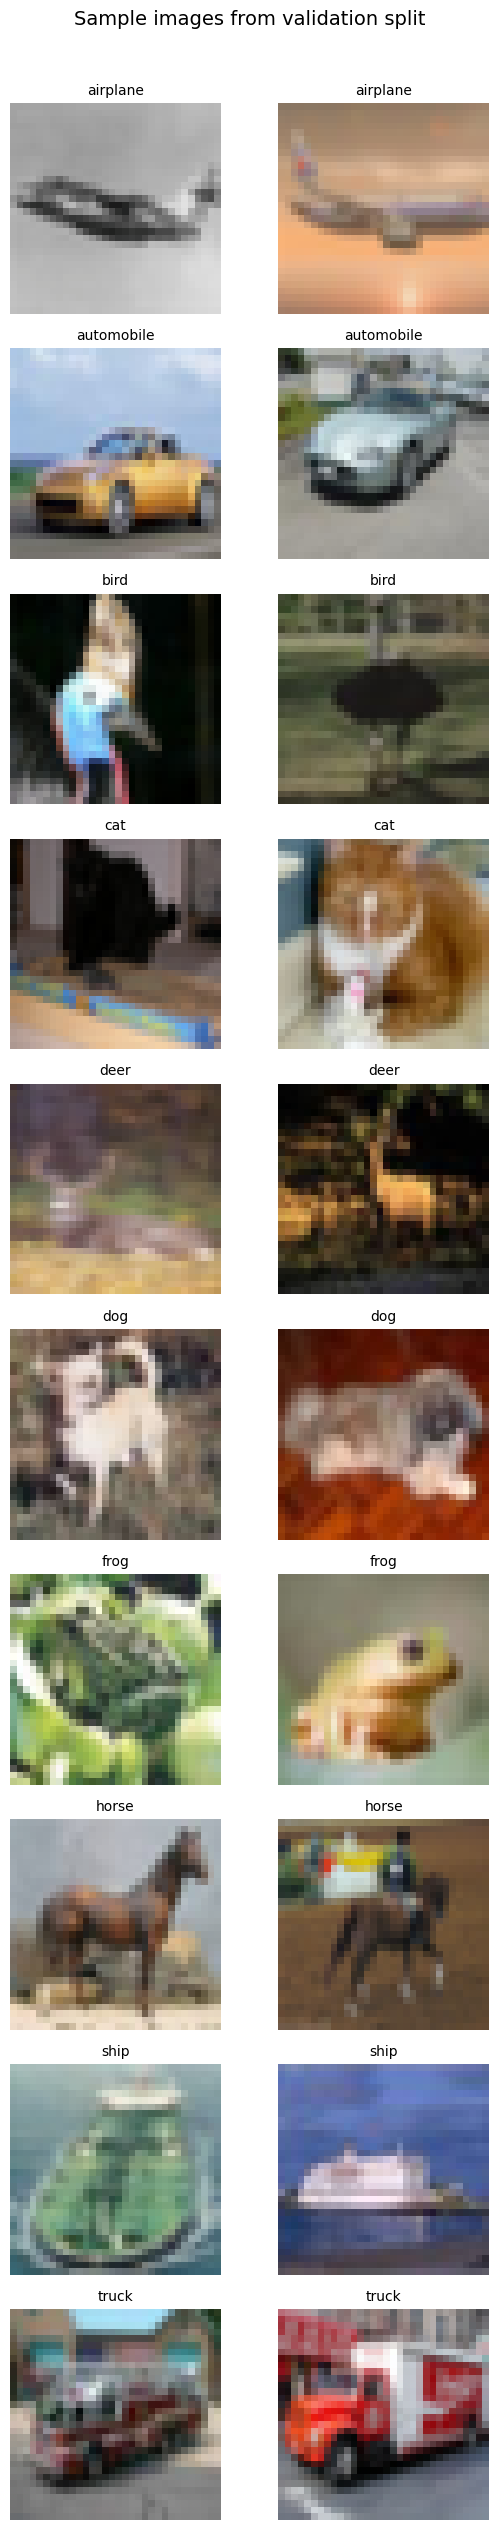

In [9]:
# Figure 2: hiển thị 2 ảnh mẫu cho mỗi lớp
samples_per_class = 2
fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 3, len(classes) * 2.5))

class_seen = {i: 0 for i in range(len(classes))}
for idx in range(len(val_dataset)):
    img, label = val_dataset[idx]
    if class_seen[label] < samples_per_class:
        ax = axes[label, class_seen[label]]
        ax.imshow(np.transpose(denormalize_img(img).numpy(), (1, 2, 0)))
        ax.set_title(classes[label], fontsize=10)
        ax.axis("off")
        class_seen[label] += 1
    if all(v >= samples_per_class for v in class_seen.values()):
        break

fig.suptitle("Sample images from validation split", fontsize=14, y=1.01)
plt.tight_layout()
save_figure(fig, "02_sample_images_per_class.png")
plt.show()

Saved figure -> outputs_part4/figures/03_augmentation_examples.png


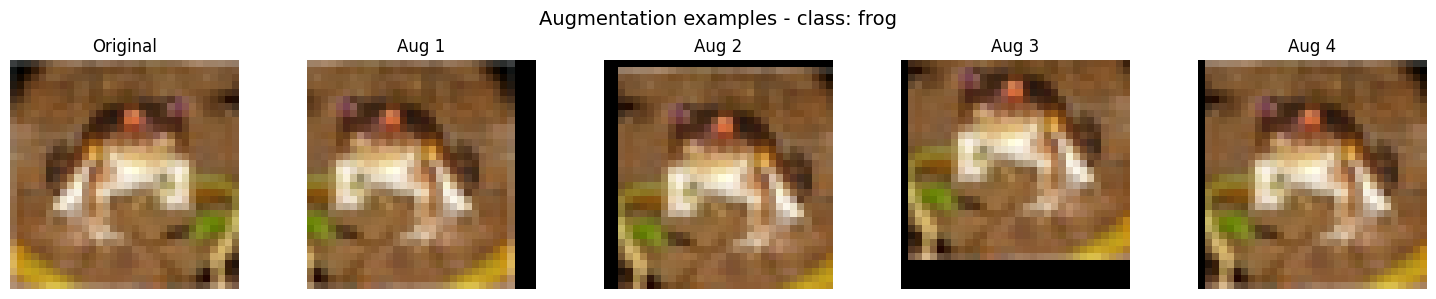

In [10]:
# Figure 3: ví dụ augmentation trên cùng 1 ảnh
raw_dataset = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=False, transform=T.ToTensor())
img0, label0 = raw_dataset[0]

aug_only = T.Compose([
    T.RandomHorizontalFlip(p=1.0),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
])

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(np.transpose(img0.numpy(), (1, 2, 0)))
axes[0].set_title("Original")
axes[0].axis("off")

pil_img0 = T.ToPILImage()(img0)
for i in range(1, 5):
    aug_img = aug_only(pil_img0)
    axes[i].imshow(np.transpose(aug_img.numpy(), (1, 2, 0)))
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

fig.suptitle(f"Augmentation examples - class: {classes[label0]}", fontsize=14)
plt.tight_layout()
save_figure(fig, "03_augmentation_examples.png")
plt.show()

## 4. Visualize các cách tokenization / embedding

Đây là phần rất hữu ích cho document vì nó cho thấy trực quan:
- patch non-overlap,
- patch overlap,
- ý tưởng spatial token và channel token.

Saved figure -> outputs_part4/figures/04_patch_non_overlap.png


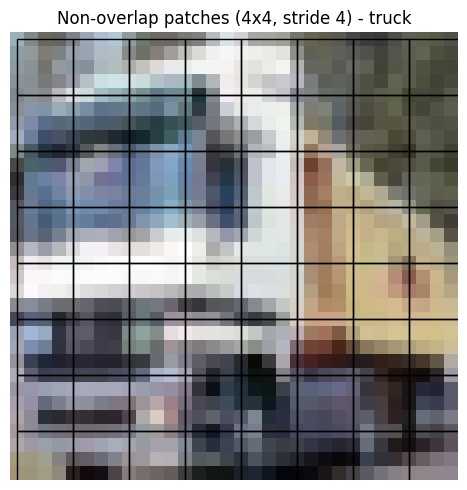

Saved figure -> outputs_part4/figures/05_patch_overlap.png


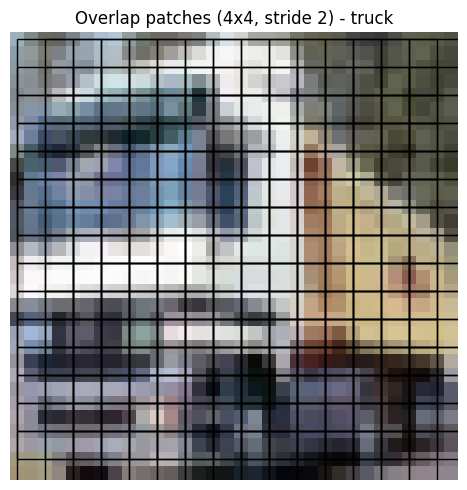

In [11]:
def plot_patch_grid(image_tensor, patch_size=4, stride=4, title="Patch grid", filename=None):
    img = np.transpose(image_tensor.numpy(), (1, 2, 0))
    H, W, _ = img.shape

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            rect = Rectangle((x, y), patch_size, patch_size, fill=False, linewidth=1.0)
            ax.add_patch(rect)

    plt.tight_layout()
    if filename is not None:
        save_figure(fig, filename)
    plt.show()

sample_img, sample_label = raw_dataset[1]
plot_patch_grid(sample_img, patch_size=4, stride=4,
                title=f"Non-overlap patches (4x4, stride 4) - {classes[sample_label]}",
                filename="04_patch_non_overlap.png")

plot_patch_grid(sample_img, patch_size=4, stride=2,
                title=f"Overlap patches (4x4, stride 2) - {classes[sample_label]}",
                filename="05_patch_overlap.png")

## 5. Utility functions

Phần này gồm:
- đếm số tham số,
- training / validation loop,
- save checkpoint,
- plot history,
- confusion matrix,
- visualize sample predictions.

Training loop được viết **thủ công bằng PyTorch** (`forward -> loss -> backward -> optimizer.step()`), đúng tinh thần rubric.

In [12]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct, total

def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct, total = accuracy_from_logits(logits, labels)
        total_correct += correct
        total_samples += total

    return {
        "loss": total_loss / total_samples,
        "acc": total_correct / total_samples
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        correct, total = accuracy_from_logits(logits, labels)
        total_correct += correct
        total_samples += total

    return {
        "loss": total_loss / total_samples,
        "acc": total_correct / total_samples
    }

def fit_model(model, train_loader, val_loader, test_loader, device, model_name, epochs=12, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
        "epoch_time_sec": [],
    }

    best_val_acc = -1.0
    best_state = None
    train_start = time.time()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_metrics = evaluate(model, val_loader, criterion, device)

        scheduler.step()
        dt = time.time() - t0

        history["epoch"].append(epoch)
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["epoch_time_sec"].append(dt)

        if val_metrics["acc"] > best_val_acc:
            best_val_acc = val_metrics["acc"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, CKPT_DIR / f"{model_name}_best.pt")

        print(
            f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} | "
            f"time={dt:.1f}s"
        )

    total_train_time = time.time() - train_start

    # load best model before test
    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_loader, criterion, device)

    result = {
        "model_name": model_name,
        "best_val_acc": best_val_acc,
        "test_acc": test_metrics["acc"],
        "test_loss": test_metrics["loss"],
        "params": count_trainable_params(model),
        "total_train_time_sec": total_train_time,
        "avg_epoch_time_sec": float(np.mean(history["epoch_time_sec"])),
        "history": pd.DataFrame(history),
        "model": model,
    }
    return result

def plot_history(history_df, model_name, save_prefix=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train acc")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Val acc")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    if save_prefix is not None:
        save_figure(fig, f"{save_prefix}_history.png")
    plt.show()

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    x_samples = []
    pred_samples = []
    true_samples = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu()

        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.numpy().tolist())

        # keep some samples for later visualization
        if len(x_samples) < 64:
            take_n = min(64 - len(x_samples), len(labels))
            x_samples.extend(images[:take_n].cpu())
            pred_samples.extend(preds[:take_n].cpu().tolist())
            true_samples.extend(labels[:take_n].cpu().tolist())

    return np.array(y_true), np.array(y_pred), x_samples, true_samples, pred_samples

def plot_confusion_mat(y_true, y_pred, class_names, title="Confusion matrix", filename=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if filename is not None:
        save_figure(fig, filename)
    plt.show()

def plot_prediction_grid(images, y_true, y_pred, class_names, title="Predictions", n=16, filename=None):
    n = min(n, len(images))
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(rows, cols)

    for idx in range(rows * cols):
        ax = axes[idx // cols, idx % cols]
        ax.axis("off")
        if idx < n:
            img = denormalize_img(images[idx])
            ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
            t = class_names[y_true[idx]]
            p = class_names[y_pred[idx]]
            color = "green" if t == p else "red"
            ax.set_title(f"T: {t}\nP: {p}", fontsize=9, color=color)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    if filename is not None:
        save_figure(fig, filename)
    plt.show()

def plot_multi_model_curves(result_dict, metric="val_acc", filename=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    for model_name, res in result_dict.items():
        df = res["history"]
        ax.plot(df["epoch"], df[metric], label=model_name)

    ax.set_title(f"Comparison of {metric} across models")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.legend()
    plt.tight_layout()
    if filename is not None:
        save_figure(fig, filename)
    plt.show()

## 6. Định nghĩa các mô hình cho Part 4

Notebook triển khai 4 kiến trúc:

### Model A - Hybrid CNN -> Transformer (Spatial Tokens)
- CNN backbone -> feature map `[B, C, H, W]`
- flatten theo **chiều không gian**
- mỗi vị trí `(h, w)` là **1 token**

### Model B - ViT Non-overlap Patch
- patch size = 4
- stride = 4
- số token = 8 x 8 = 64

### Model C - ViT Overlap Patch
- patch size = 4
- stride = 2
- số token = 15 x 15 = 225

### Model D - Hybrid CNN -> Transformer (Channel Tokens)
- CNN backbone -> feature map `[B, C, H, W]`
- mỗi **channel** là **1 token**
- token dimension ban đầu là `H x W`

Mô hình D giúp align trực tiếp với gợi ý trong đề về việc xem **chiều kênh C như token**.

In [13]:
# =========================
# MODEL BUILDING BLOCKS
# =========================
class TransformerClassifierCore(nn.Module):
    def __init__(self, embed_dim, num_heads, depth, num_classes, max_tokens, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, max_tokens + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward_tokens(self, tokens):
        B, N, D = tokens.shape
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, tokens], dim=1)
        x = x + self.pos_embed[:, :N + 1, :]
        x = self.dropout(x)
        x = self.encoder(x)
        x = self.norm(x[:, 0])
        logits = self.head(x)
        return logits

class PatchEmbed(nn.Module):
    def __init__(self, in_chans=3, embed_dim=96, kernel_size=4, stride=4):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=kernel_size, stride=stride)

    def forward(self, x):
        x = self.proj(x)                    # [B, D, H', W']
        B, D, H, W = x.shape
        tokens = x.flatten(2).transpose(1, 2)  # [B, N, D]
        return tokens, (H, W)

class SmallCNNBackbone(nn.Module):
    def __init__(self, out_channels=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.GELU(),

            nn.Conv2d(96, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.MaxPool2d(2),  # 16 -> 8
        )

    def forward(self, x):
        return self.net(x)  # [B, C, 8, 8]

In [14]:
# =========================
# MODEL A: Hybrid CNN -> Transformer (Spatial Tokens)
# =========================
class HybridCNNSpatialTokens(nn.Module):
    def __init__(self, num_classes=10, cnn_channels=128, embed_dim=96, num_heads=4, depth=3, dropout=0.1):
        super().__init__()
        self.backbone = SmallCNNBackbone(out_channels=cnn_channels)
        self.token_proj = nn.Linear(cnn_channels, embed_dim)
        self.classifier = TransformerClassifierCore(
            embed_dim=embed_dim,
            num_heads=num_heads,
            depth=depth,
            num_classes=num_classes,
            max_tokens=8 * 8,
            dropout=dropout,
        )
        self.token_count = 64
        self.token_type = "Spatial tokens from CNN feature map"

    def forward(self, x):
        feat = self.backbone(x)                  # [B, C, 8, 8]
        tokens = feat.flatten(2).transpose(1, 2)  # [B, 64, C]
        tokens = self.token_proj(tokens)         # [B, 64, embed_dim]
        return self.classifier.forward_tokens(tokens)

# =========================
# MODEL B: ViT Non-overlap Patch
# =========================
class ViTNonOverlap(nn.Module):
    def __init__(self, num_classes=10, embed_dim=96, num_heads=4, depth=3, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(in_chans=3, embed_dim=embed_dim, kernel_size=4, stride=4)
        self.classifier = TransformerClassifierCore(
            embed_dim=embed_dim,
            num_heads=num_heads,
            depth=depth,
            num_classes=num_classes,
            max_tokens=64,
            dropout=dropout,
        )
        self.token_count = 64
        self.token_type = "Non-overlap patches (4x4, stride 4)"

    def forward(self, x):
        tokens, _ = self.patch_embed(x)
        return self.classifier.forward_tokens(tokens)

# =========================
# MODEL C: ViT Overlap Patch
# =========================
class ViTOverlap(nn.Module):
    def __init__(self, num_classes=10, embed_dim=96, num_heads=4, depth=3, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(in_chans=3, embed_dim=embed_dim, kernel_size=4, stride=2)
        self.classifier = TransformerClassifierCore(
            embed_dim=embed_dim,
            num_heads=num_heads,
            depth=depth,
            num_classes=num_classes,
            max_tokens=225,
            dropout=dropout,
        )
        self.token_count = 225
        self.token_type = "Overlap patches (4x4, stride 2)"

    def forward(self, x):
        tokens, _ = self.patch_embed(x)
        return self.classifier.forward_tokens(tokens)

# =========================
# MODEL D: Hybrid CNN -> Transformer (Channel Tokens)
# =========================
class HybridCNNChannelTokens(nn.Module):
    def __init__(self, num_classes=10, cnn_channels=128, embed_dim=96, num_heads=4, depth=3, dropout=0.1):
        super().__init__()
        self.backbone = SmallCNNBackbone(out_channels=cnn_channels)
        self.token_proj = nn.Linear(8 * 8, embed_dim)
        self.classifier = TransformerClassifierCore(
            embed_dim=embed_dim,
            num_heads=num_heads,
            depth=depth,
            num_classes=num_classes,
            max_tokens=cnn_channels,
            dropout=dropout,
        )
        self.token_count = cnn_channels
        self.token_type = "Channel tokens from CNN feature map"

    def forward(self, x):
        feat = self.backbone(x)     # [B, C, 8, 8]
        tokens = feat.flatten(2)    # [B, C, 64]  -> mỗi channel là 1 token
        tokens = self.token_proj(tokens)  # [B, C, embed_dim]
        return self.classifier.forward_tokens(tokens)

In [15]:
# Smoke test: kiểm tra output shape để chắc chắn notebook chạy ổn
dummy_x = torch.randn(4, 3, 32, 32)

models_smoke = {
    "HybridCNNSpatialTokens": HybridCNNSpatialTokens(),
    "ViTNonOverlap": ViTNonOverlap(),
    "ViTOverlap": ViTOverlap(),
    "HybridCNNChannelTokens": HybridCNNChannelTokens(),
}

for name, model in models_smoke.items():
    out = model(dummy_x)
    print(name, "->", out.shape, "| params =", count_trainable_params(model))

/tmp/ipykernel_8062/1472780447.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


HybridCNNSpatialTokens -> torch.Size([4, 10]) | params = 541546
ViTNonOverlap -> torch.Size([4, 10]) | params = 347722
ViTOverlap -> torch.Size([4, 10]) | params = 363178
HybridCNNChannelTokens -> torch.Size([4, 10]) | params = 541546


## 7. Bảng mô tả thực nghiệm

Cell dưới đây tạo ra bảng mô tả các mô hình để bạn có thể chụp hoặc export sang báo cáo.

In [16]:
experiment_builders = {
    "HybridCNNSpatialTokens": lambda: HybridCNNSpatialTokens(),
    "ViTNonOverlap": lambda: ViTNonOverlap(),
    "ViTOverlap": lambda: ViTOverlap(),
    "HybridCNNChannelTokens": lambda: HybridCNNChannelTokens(),
}

model_specs = []
for name, builder in experiment_builders.items():
    model = builder()
    model_specs.append({
        "model_name": name,
        "token_type": model.token_type,
        "token_count": model.token_count,
        "params": count_trainable_params(model),
    })

spec_df = pd.DataFrame(model_specs).sort_values("params")
display(spec_df)
spec_df.to_csv(TABLE_DIR / "model_specs.csv", index=False)
print("Saved ->", TABLE_DIR / "model_specs.csv")

/tmp/ipykernel_8062/1472780447.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


,model_name,token_type,token_count,params
1,ViTNonOverlap,"Non-overlap patches (4x4, stride 4)",64,347722
2,ViTOverlap,"Overlap patches (4x4, stride 2)",225,363178
0,HybridCNNSpatialTokens,Spatial tokens from CNN feature map,64,541546
3,HybridCNNChannelTokens,Channel tokens from CNN feature map,128,541546


Saved -> outputs_part4/tables/model_specs.csv


Saved figure -> outputs_part4/figures/06_token_and_param_comparison_magma.png


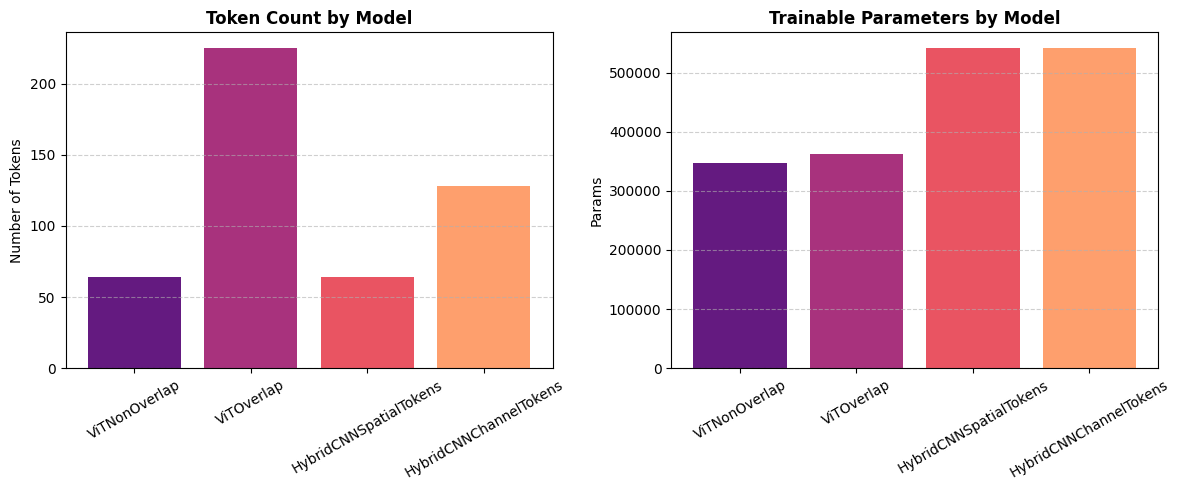

In [25]:
# Thiết lập style và khởi tạo figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tạo danh sách màu dựa trên bảng màu 'magma'
# Chúng ta sẽ lấy số lượng màu tương ứng với số lượng dòng trong spec_df
colors = cm.magma(np.linspace(0.3, 0.8, len(spec_df)))

# Chart 1: Token count
bars0 = axes[0].bar(spec_df["model_name"], spec_df["token_count"], color=colors)
axes[0].set_title("Token Count by Model", fontweight='bold')
axes[0].set_ylabel("Number of Tokens")
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Trainable parameters
# Thử dùng đảo ngược màu hoặc giữ nguyên để đồng bộ
bars1 = axes[1].bar(spec_df["model_name"], spec_df["params"], color=colors)
axes[1].set_title("Trainable Parameters by Model", fontweight='bold')
axes[1].set_ylabel("Params")
axes[1].tick_params(axis='x', rotation=30)

# Thêm lưới mờ cho hiện đại
axes[0].yaxis.grid(True, linestyle='--', alpha=0.6)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Lưu và hiển thị
save_figure(fig, "06_token_and_param_comparison_magma.png")
plt.show()

## 8. Huấn luyện tất cả mô hình

- cùng optimizer / scheduler / batch size / số epoch,
- cùng train / val / test split,
- lưu lại:
  - checkpoint tốt nhất theo validation accuracy,
  - history theo epoch,
  - kết quả test cuối cùng.

> Nếu muốn chạy nhanh thử notebook trước, hãy đặt `FAST_MODE = True` ở phần config rồi restart runtime.

Training model: HybridCNNSpatialTokens


/tmp/ipykernel_8062/1472780447.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_8062/3767372794.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


[HybridCNNSpatialTokens] Epoch 01/12 | train_loss=1.4806 train_acc=0.4507 | val_loss=1.3120 val_acc=0.5206 | time=44.2s
[HybridCNNSpatialTokens] Epoch 02/12 | train_loss=1.0471 train_acc=0.6229 | val_loss=1.1069 val_acc=0.6048 | time=28.2s
[HybridCNNSpatialTokens] Epoch 03/12 | train_loss=0.8787 train_acc=0.6882 | val_loss=0.9275 val_acc=0.6720 | time=28.2s
[HybridCNNSpatialTokens] Epoch 04/12 | train_loss=0.7615 train_acc=0.7328 | val_loss=0.7914 val_acc=0.7232 | time=28.1s
[HybridCNNSpatialTokens] Epoch 05/12 | train_loss=0.6764 train_acc=0.7638 | val_loss=0.6663 val_acc=0.7726 | time=28.7s
[HybridCNNSpatialTokens] Epoch 06/12 | train_loss=0.6050 train_acc=0.7889 | val_loss=0.6400 val_acc=0.7810 | time=28.0s
[HybridCNNSpatialTokens] Epoch 07/12 | train_loss=0.5471 train_acc=0.8094 | val_loss=0.6019 val_acc=0.8016 | time=28.2s
[HybridCNNSpatialTokens] Epoch 08/12 | train_loss=0.4889 train_acc=0.8308 | val_loss=0.5263 val_acc=0.8194 | time=28.8s
[HybridCNNSpatialTokens] Epoch 09/12 | t

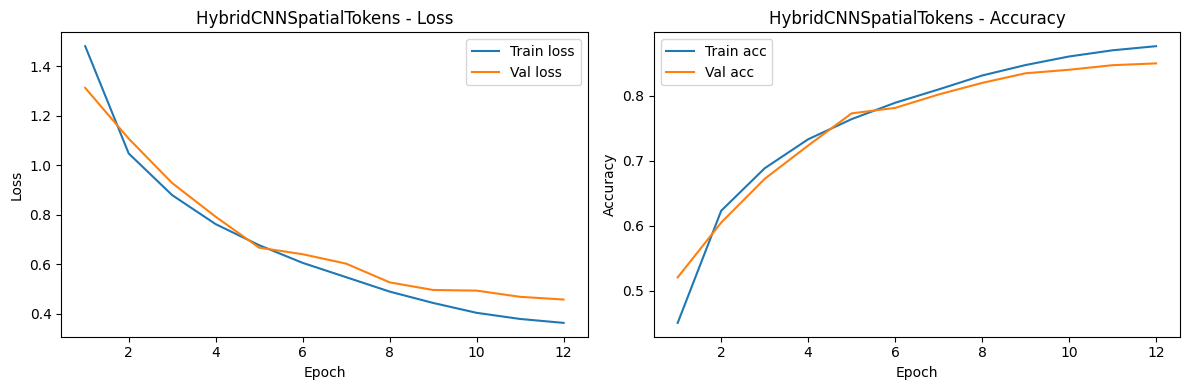

Saved figure -> outputs_part4/figures/HybridCNNSpatialTokens_confusion_matrix.png


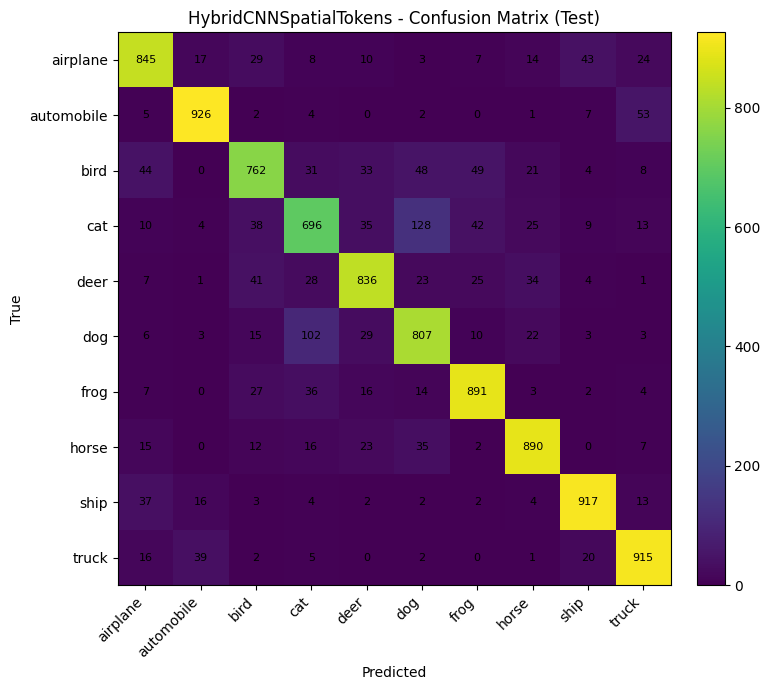

Saved figure -> outputs_part4/figures/HybridCNNSpatialTokens_sample_predictions.png


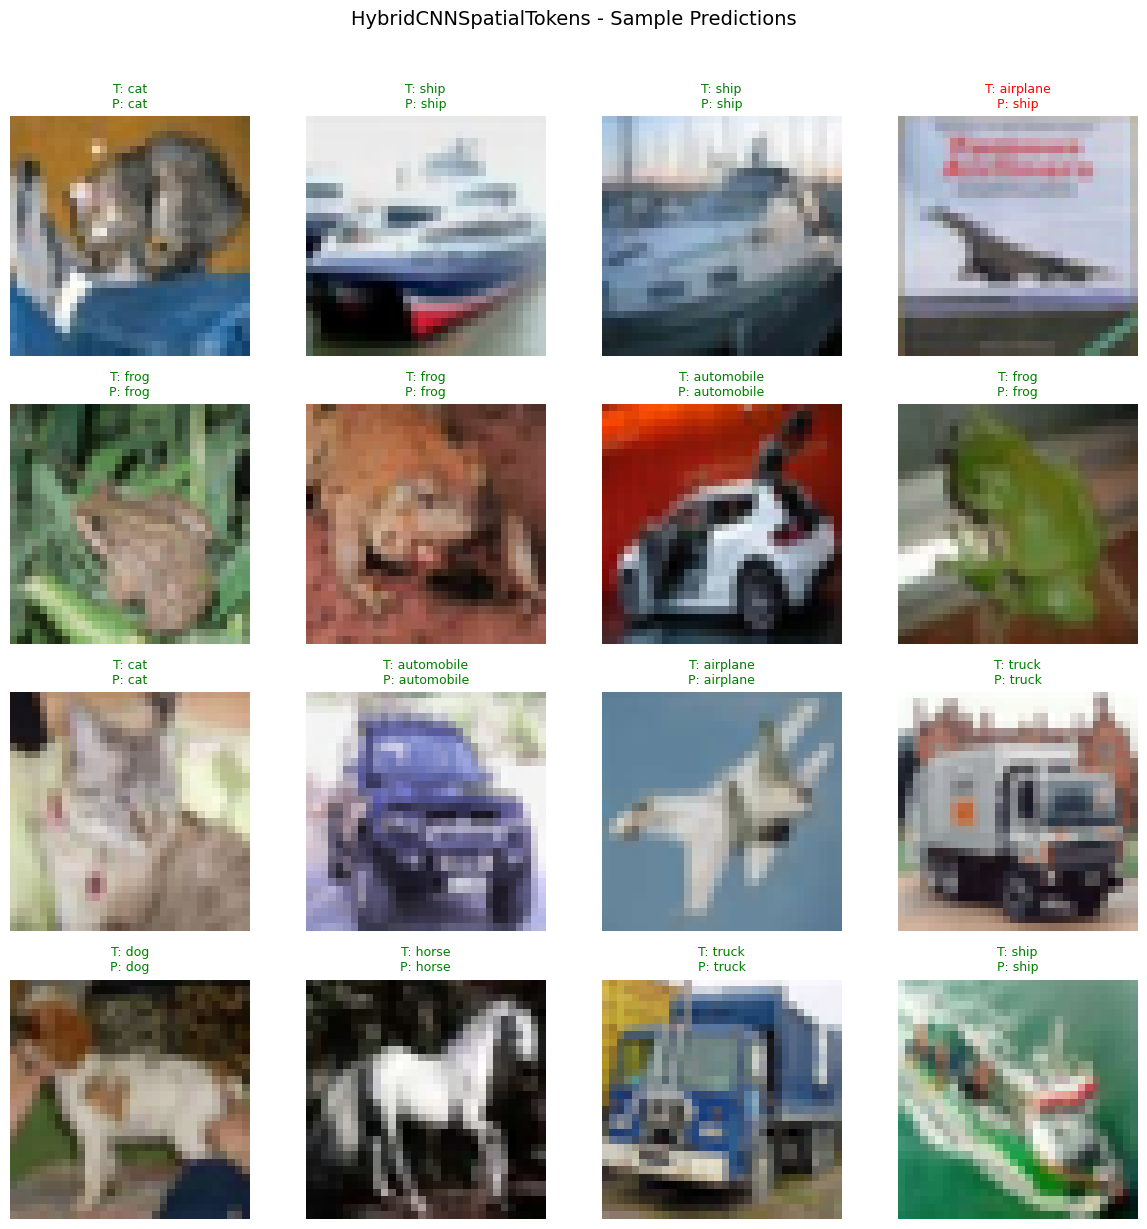

Training model: ViTNonOverlap


/tmp/ipykernel_8062/1472780447.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_8062/3767372794.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


[ViTNonOverlap] Epoch 01/12 | train_loss=1.8128 train_acc=0.3203 | val_loss=1.6102 val_acc=0.3928 | time=23.7s
[ViTNonOverlap] Epoch 02/12 | train_loss=1.5492 train_acc=0.4280 | val_loss=1.4941 val_acc=0.4436 | time=23.9s
[ViTNonOverlap] Epoch 03/12 | train_loss=1.4182 train_acc=0.4832 | val_loss=1.2932 val_acc=0.5284 | time=24.0s
[ViTNonOverlap] Epoch 04/12 | train_loss=1.3344 train_acc=0.5121 | val_loss=1.2614 val_acc=0.5362 | time=23.6s
[ViTNonOverlap] Epoch 05/12 | train_loss=1.2601 train_acc=0.5425 | val_loss=1.1834 val_acc=0.5740 | time=23.6s
[ViTNonOverlap] Epoch 06/12 | train_loss=1.2009 train_acc=0.5640 | val_loss=1.1284 val_acc=0.5936 | time=23.7s
[ViTNonOverlap] Epoch 07/12 | train_loss=1.1508 train_acc=0.5823 | val_loss=1.0744 val_acc=0.6114 | time=23.5s
[ViTNonOverlap] Epoch 08/12 | train_loss=1.1010 train_acc=0.6022 | val_loss=1.0309 val_acc=0.6282 | time=23.6s
[ViTNonOverlap] Epoch 09/12 | train_loss=1.0505 train_acc=0.6201 | val_loss=1.0106 val_acc=0.6376 | time=23.6s
[

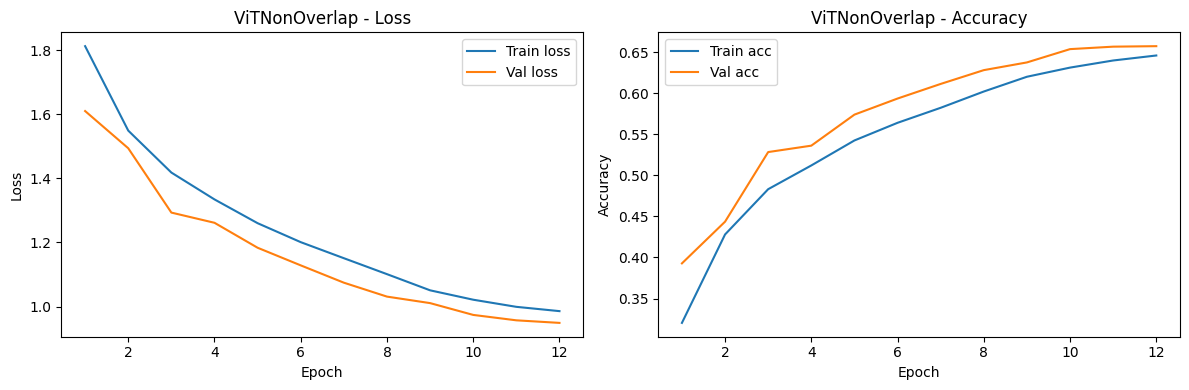

Saved figure -> outputs_part4/figures/ViTNonOverlap_confusion_matrix.png


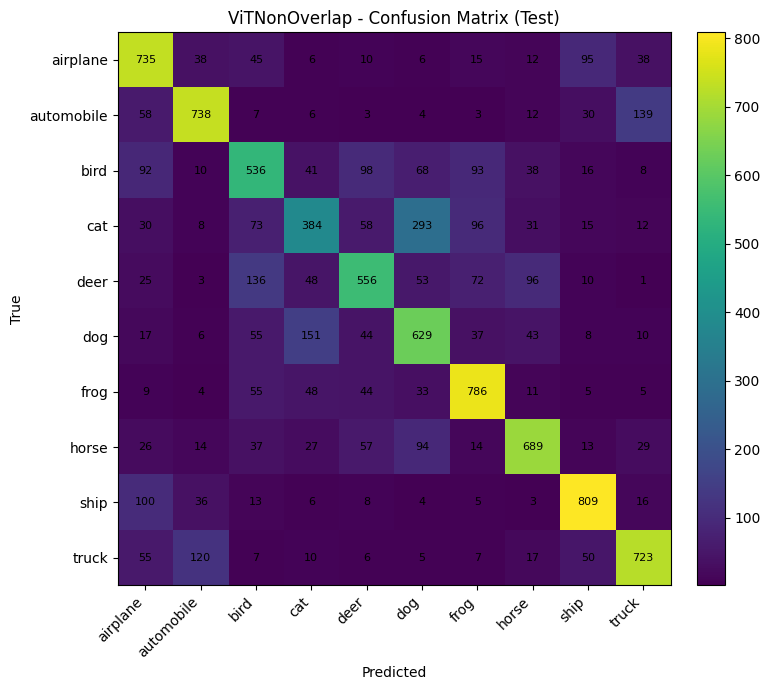

Saved figure -> outputs_part4/figures/ViTNonOverlap_sample_predictions.png


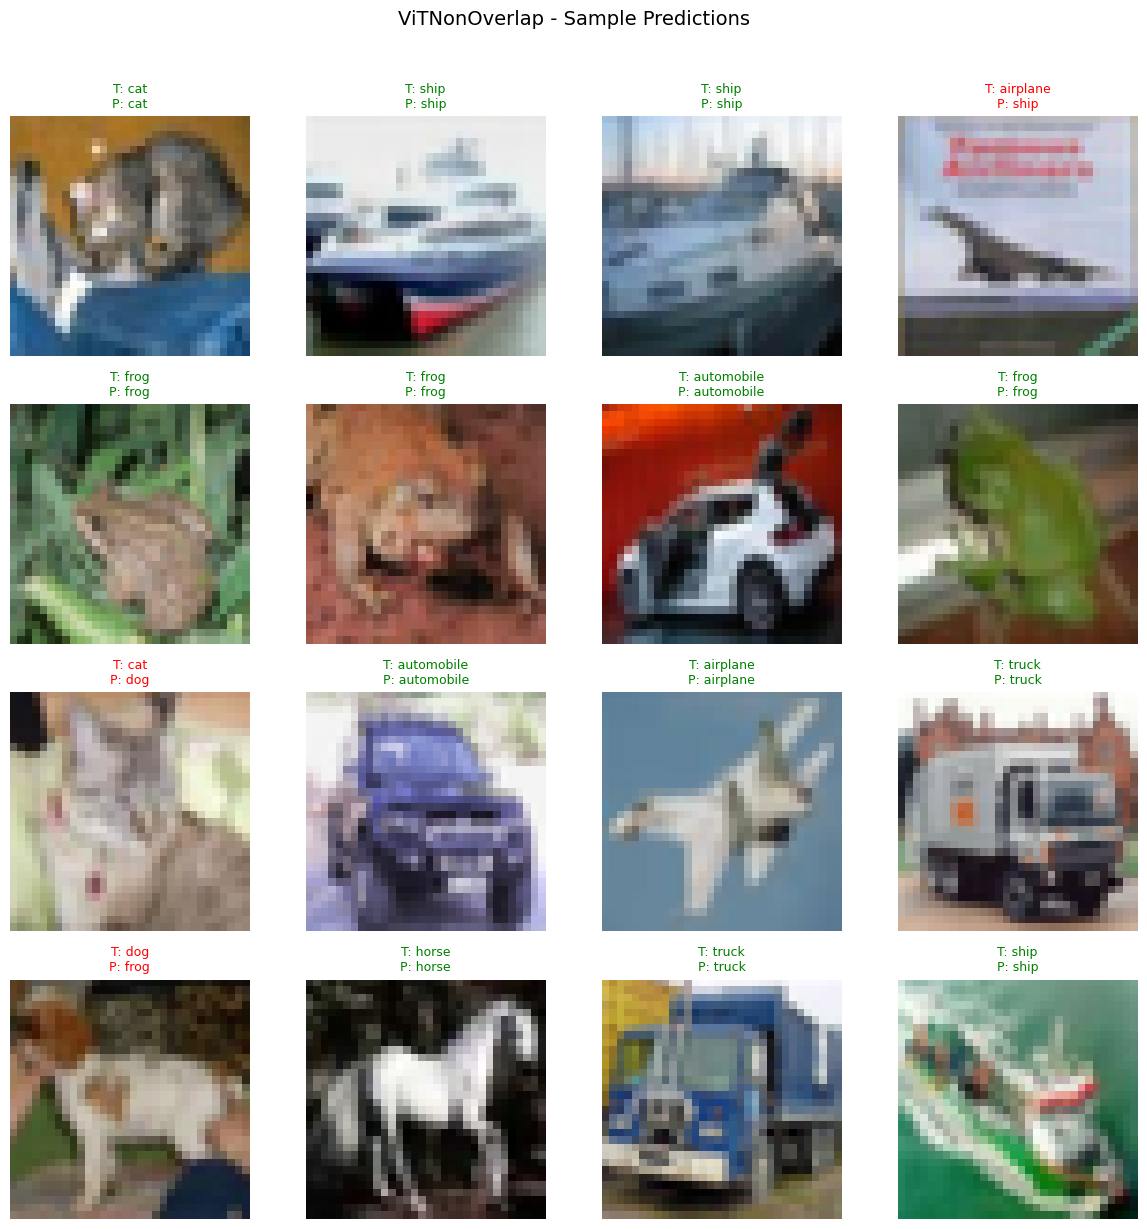

Training model: ViTOverlap


/tmp/ipykernel_8062/1472780447.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_8062/3767372794.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


[ViTOverlap] Epoch 01/12 | train_loss=1.7080 train_acc=0.3584 | val_loss=1.4861 val_acc=0.4496 | time=30.4s
[ViTOverlap] Epoch 02/12 | train_loss=1.4054 train_acc=0.4828 | val_loss=1.2791 val_acc=0.5338 | time=29.4s
[ViTOverlap] Epoch 03/12 | train_loss=1.2766 train_acc=0.5344 | val_loss=1.1910 val_acc=0.5732 | time=29.8s
[ViTOverlap] Epoch 04/12 | train_loss=1.1863 train_acc=0.5710 | val_loss=1.1067 val_acc=0.5926 | time=29.8s
[ViTOverlap] Epoch 05/12 | train_loss=1.1095 train_acc=0.6016 | val_loss=1.0411 val_acc=0.6306 | time=29.8s
[ViTOverlap] Epoch 06/12 | train_loss=1.0513 train_acc=0.6202 | val_loss=0.9935 val_acc=0.6492 | time=30.1s
[ViTOverlap] Epoch 07/12 | train_loss=0.9922 train_acc=0.6442 | val_loss=0.9220 val_acc=0.6766 | time=29.8s
[ViTOverlap] Epoch 08/12 | train_loss=0.9368 train_acc=0.6647 | val_loss=0.8996 val_acc=0.6802 | time=30.2s
[ViTOverlap] Epoch 09/12 | train_loss=0.8958 train_acc=0.6802 | val_loss=0.8552 val_acc=0.6938 | time=29.5s
[ViTOverlap] Epoch 10/12 | t

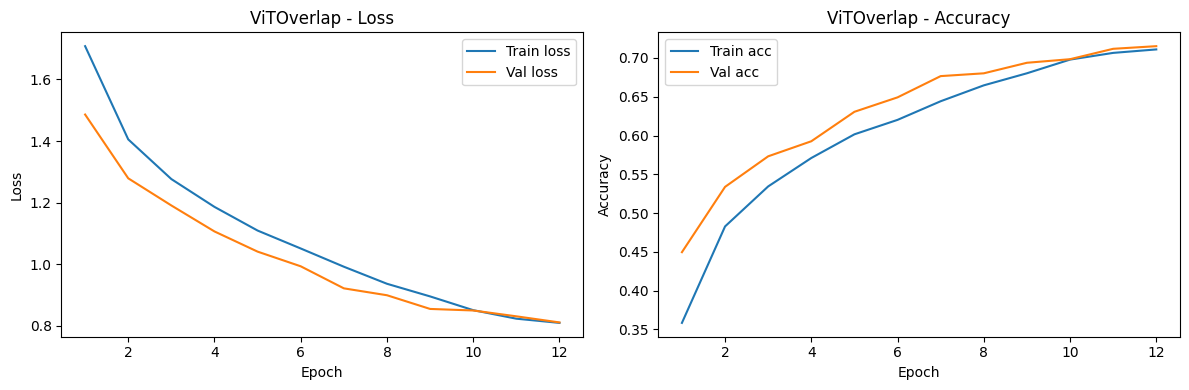

Saved figure -> outputs_part4/figures/ViTOverlap_confusion_matrix.png


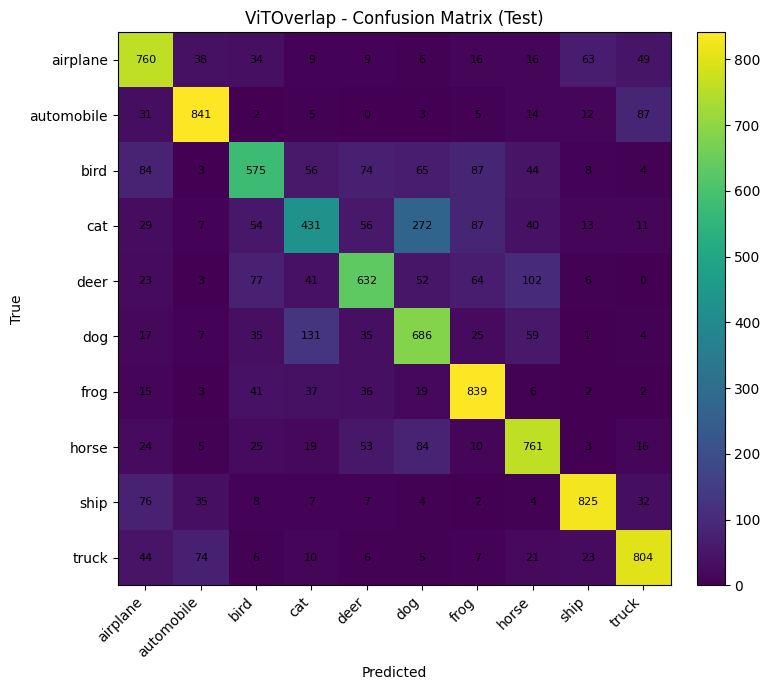

Saved figure -> outputs_part4/figures/ViTOverlap_sample_predictions.png


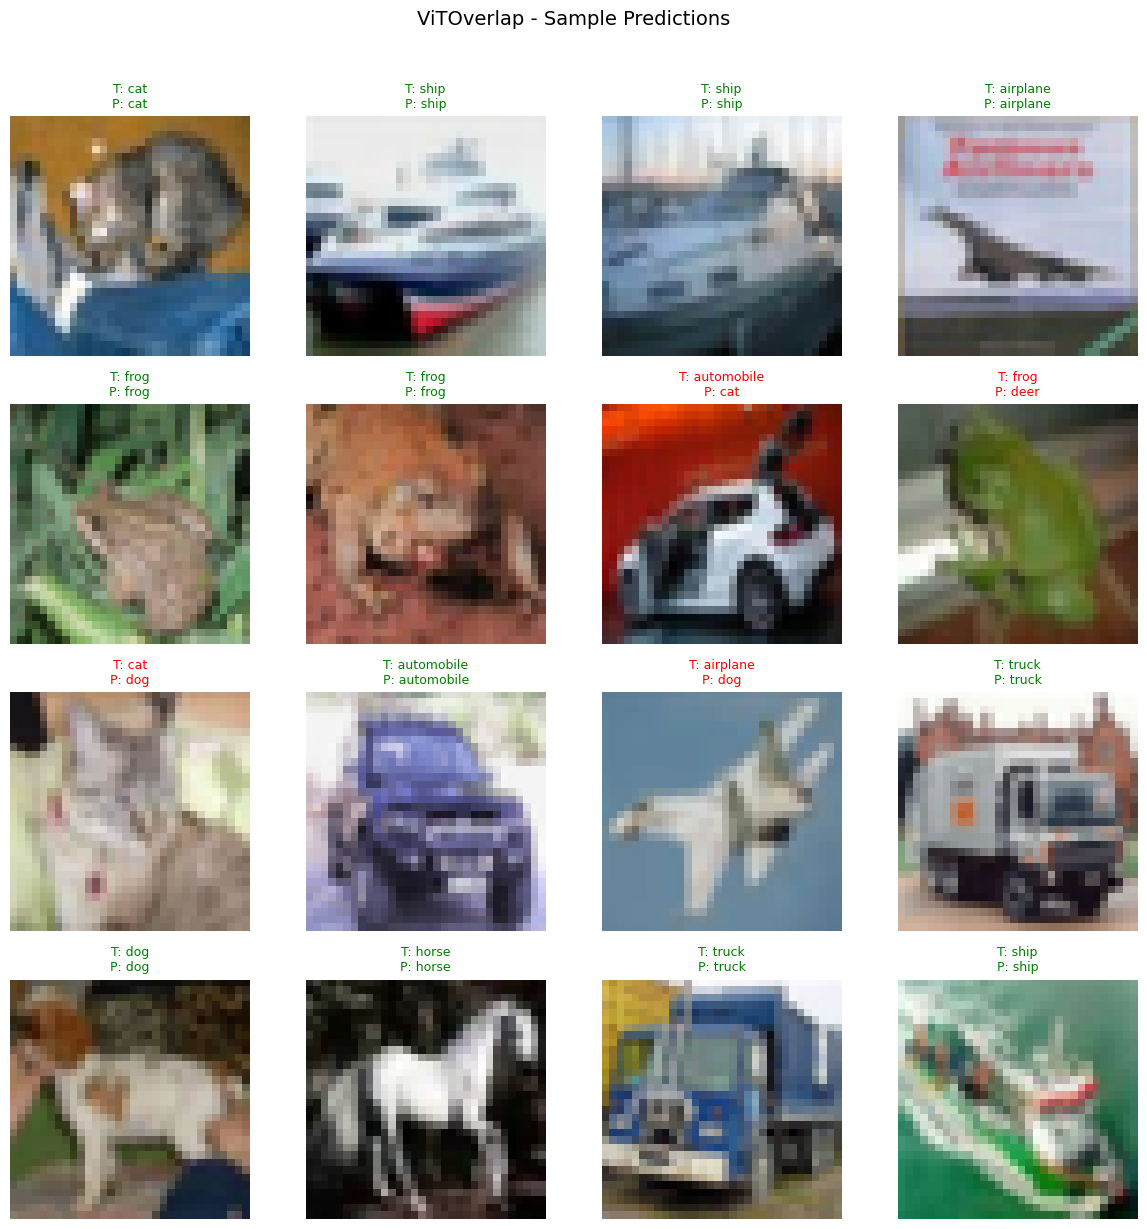

Training model: HybridCNNChannelTokens


/tmp/ipykernel_8062/1472780447.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_8062/3767372794.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


[HybridCNNChannelTokens] Epoch 01/12 | train_loss=1.6785 train_acc=0.3746 | val_loss=1.3664 val_acc=0.4980 | time=28.6s
[HybridCNNChannelTokens] Epoch 02/12 | train_loss=1.3192 train_acc=0.5192 | val_loss=1.1776 val_acc=0.5612 | time=28.7s
[HybridCNNChannelTokens] Epoch 03/12 | train_loss=1.1551 train_acc=0.5822 | val_loss=1.0198 val_acc=0.6316 | time=28.5s
[HybridCNNChannelTokens] Epoch 04/12 | train_loss=1.0406 train_acc=0.6252 | val_loss=1.0337 val_acc=0.6234 | time=28.5s
[HybridCNNChannelTokens] Epoch 05/12 | train_loss=0.9498 train_acc=0.6605 | val_loss=0.9782 val_acc=0.6534 | time=28.5s
[HybridCNNChannelTokens] Epoch 06/12 | train_loss=0.8802 train_acc=0.6856 | val_loss=0.9006 val_acc=0.6784 | time=28.2s
[HybridCNNChannelTokens] Epoch 07/12 | train_loss=0.8183 train_acc=0.7086 | val_loss=0.8526 val_acc=0.7002 | time=27.8s
[HybridCNNChannelTokens] Epoch 08/12 | train_loss=0.7711 train_acc=0.7253 | val_loss=0.7306 val_acc=0.7378 | time=28.9s
[HybridCNNChannelTokens] Epoch 09/12 | t

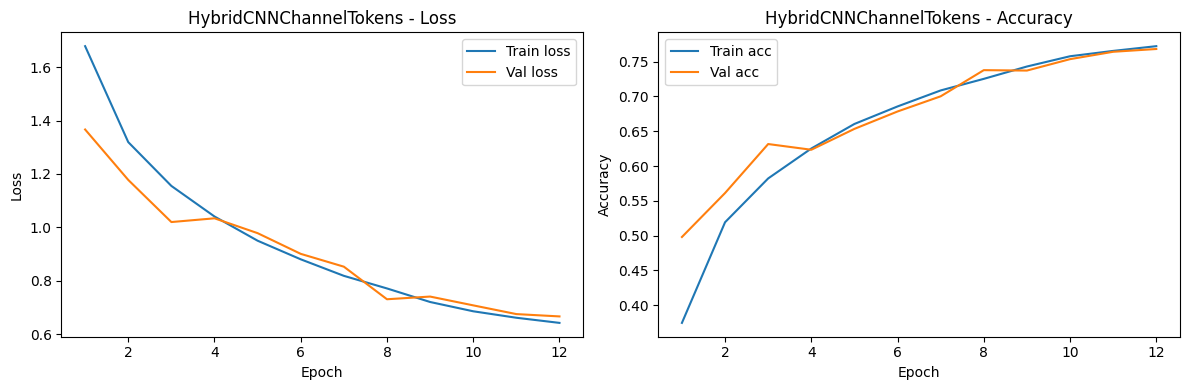

Saved figure -> outputs_part4/figures/HybridCNNChannelTokens_confusion_matrix.png


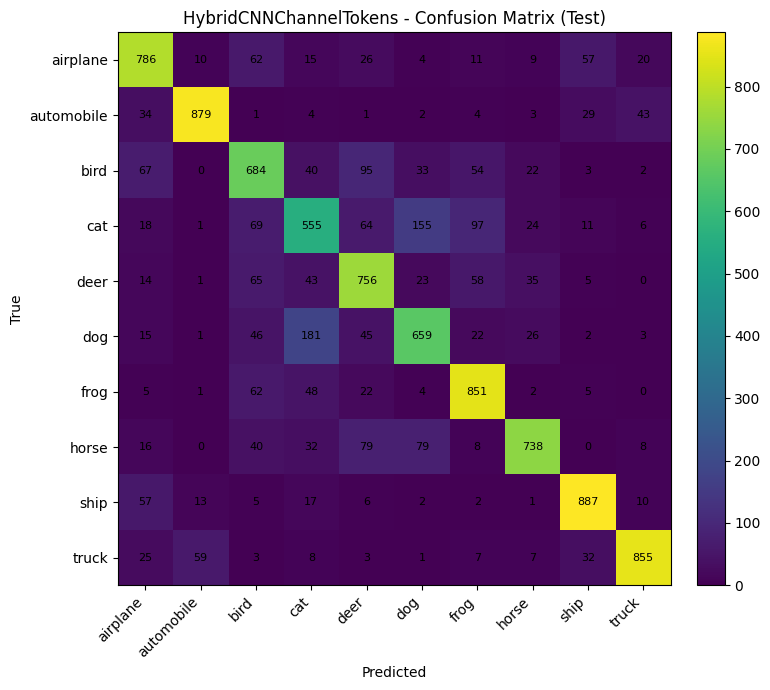

Saved figure -> outputs_part4/figures/HybridCNNChannelTokens_sample_predictions.png


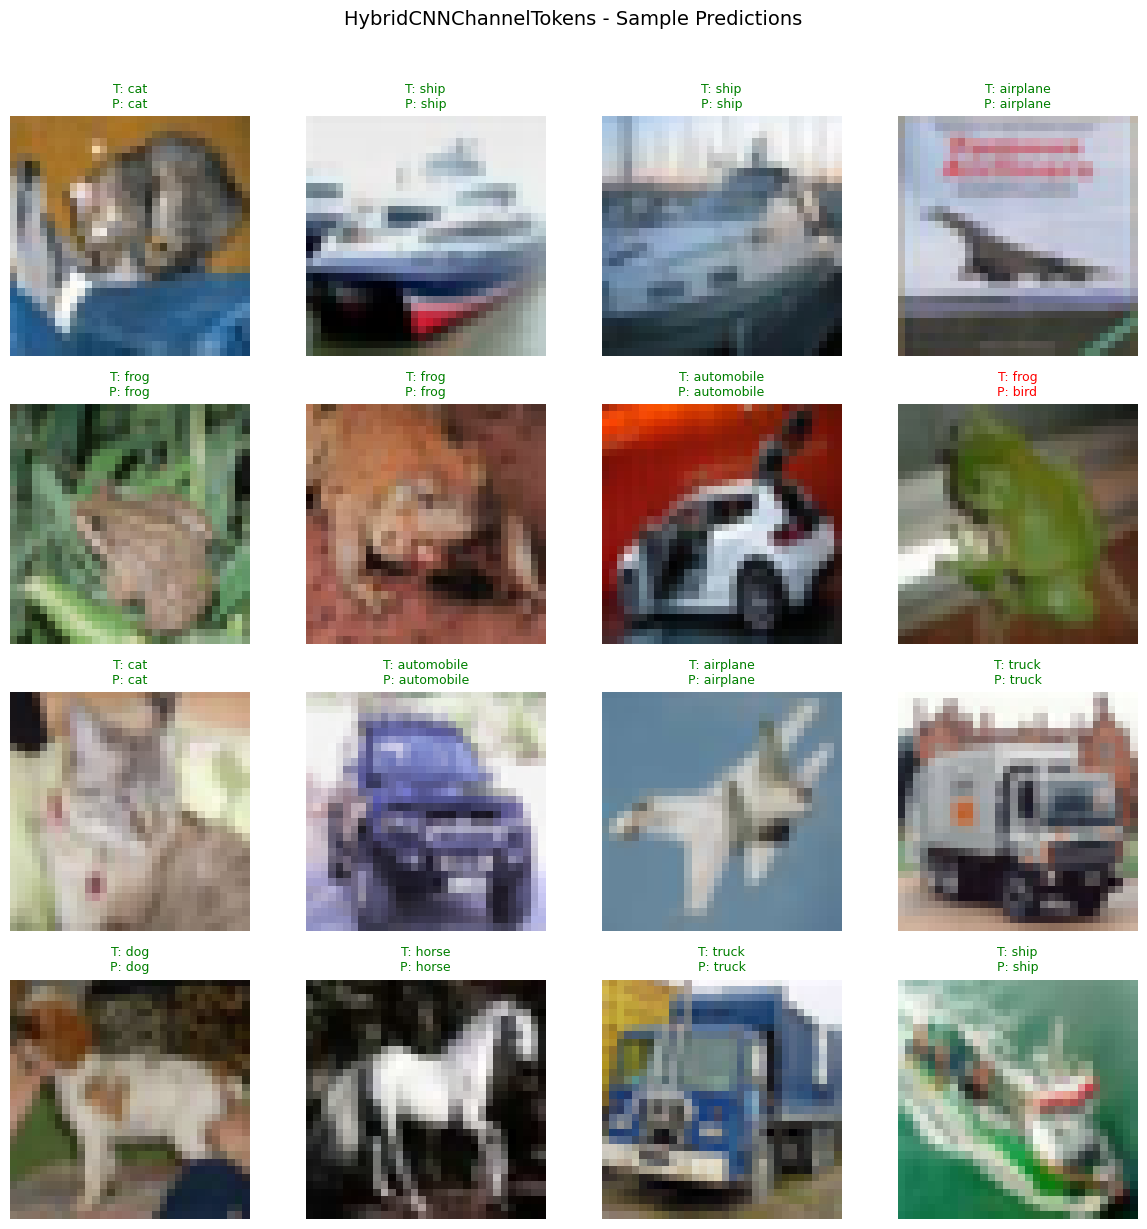

In [18]:
all_results = {}

for model_name, builder in experiment_builders.items():
    print("=" * 90)
    print("Training model:", model_name)
    print("=" * 90)

    model = builder()
    result = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=DEVICE,
        model_name=model_name,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )
    all_results[model_name] = result

    # Save per-model history
    history_df = result["history"]
    history_path = TABLE_DIR / f"{model_name}_history.csv"
    history_df.to_csv(history_path, index=False)
    print("Saved history ->", history_path)

    # Plot per-model history
    plot_history(history_df, model_name=model_name, save_prefix=model_name)

    # Confusion matrix and sample predictions
    y_true, y_pred, sample_images, sample_true, sample_pred = predict_loader(result["model"], test_loader, DEVICE)
    plot_confusion_mat(
        y_true, y_pred, classes,
        title=f"{model_name} - Confusion Matrix (Test)",
        filename=f"{model_name}_confusion_matrix.png"
    )
    plot_prediction_grid(
        sample_images, sample_true, sample_pred, classes,
        title=f"{model_name} - Sample Predictions",
        n=16,
        filename=f"{model_name}_sample_predictions.png"
    )

## 9. Tổng hợp kết quả

Cell dưới đây tổng hợp:
- best validation accuracy,
- test accuracy,
- test loss,
- số tham số,
- thời gian train.

Đây là bảng chính để bạn đưa vào phần so sánh của báo cáo.

In [19]:
summary_rows = []
for model_name, res in all_results.items():
    model_ref = res["model"]
    summary_rows.append({
        "model_name": model_name,
        "token_type": model_ref.token_type,
        "token_count": model_ref.token_count,
        "params": res["params"],
        "best_val_acc": res["best_val_acc"],
        "test_acc": res["test_acc"],
        "test_loss": res["test_loss"],
        "avg_epoch_time_sec": res["avg_epoch_time_sec"],
        "total_train_time_sec": res["total_train_time_sec"],
    })

results_df = pd.DataFrame(summary_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(results_df)

results_df.to_csv(TABLE_DIR / "part4_results_summary.csv", index=False)
print("Saved ->", TABLE_DIR / "part4_results_summary.csv")

,model_name,token_type,token_count,params,best_val_acc,test_acc,test_loss,avg_epoch_time_sec,total_train_time_sec
0,HybridCNNSpatialTokens,Spatial tokens from CNN feature map,64,541546,0.8494,0.8485,0.453096,29.521921,354.436280
1,HybridCNNChannelTokens,Channel tokens from CNN feature map,128,541546,0.7682,0.7650,0.667654,28.422058,341.199664
2,ViTOverlap,"Overlap patches (4x4, stride 2)",225,363178,0.7152,0.7154,0.803921,29.831986,358.097483
3,ViTNonOverlap,"Non-overlap patches (4x4, stride 4)",64,347722,0.6574,0.6585,0.945457,23.652175,283.928575


Saved -> outputs_part4/tables/part4_results_summary.csv


Saved figure -> outputs_part4/figures/07_final_bar_comparison.png


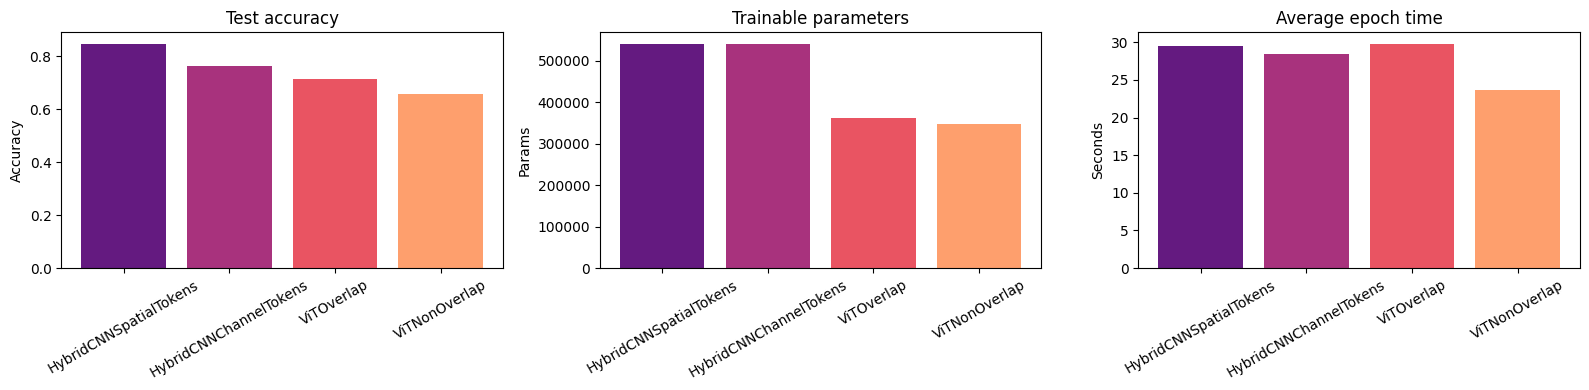

In [29]:
# Figure: so sánh accuracy / params / time
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tạo bảng màu magma dựa trên số lượng model trong results_df
colors = cm.magma(np.linspace(0.3, 0.8, len(results_df)))

# Chart 0: Accuracy
axes[0].bar(results_df["model_name"], results_df["test_acc"], color=colors)
axes[0].set_title("Test accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis='x', rotation=30)

# Chart 1: Params
axes[1].bar(results_df["model_name"], results_df["params"], color=colors)
axes[1].set_title("Trainable parameters")
axes[1].set_ylabel("Params")
axes[1].tick_params(axis='x', rotation=30)

# Chart 2: Time
axes[2].bar(results_df["model_name"], results_df["avg_epoch_time_sec"], color=colors)
axes[2].set_title("Average epoch time")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
save_figure(fig, "07_final_bar_comparison.png")
plt.show()

Saved figure -> outputs_part4/figures/08_accuracy_vs_params_magma.png


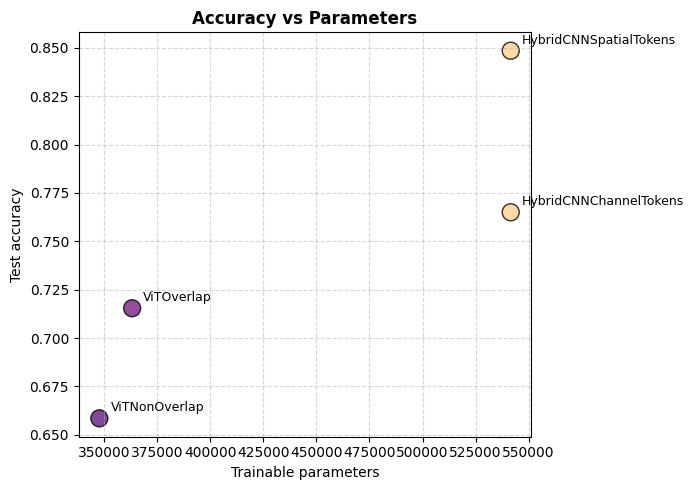

In [37]:
# Figure: trade-off giữa độ chính xác và số tham số
fig, ax = plt.subplots(figsize=(7, 5))

# Tạo màu dựa trên vị trí của số lượng tham số (params)
norm = plt.Normalize(results_df["params"].min(), results_df["params"].max())
colors = cm.magma(norm(results_df["params"]) * 0.6 + 0.3)

# Vẽ scatter với màu magma
ax.scatter(results_df["params"], results_df["test_acc"], s=150, c=colors, edgecolor='black', alpha=0.8)

for _, row in results_df.iterrows():
    ax.annotate(row["model_name"], (row["params"], row["test_acc"]),
                xytext=(8, 5), textcoords="offset points", fontsize=9)

ax.set_title("Accuracy vs Parameters", fontweight='bold')
ax.set_xlabel("Trainable parameters")
ax.set_ylabel("Test accuracy")

# Thêm lưới cho dễ quan sát tọa độ
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_figure(fig, "08_accuracy_vs_params_magma.png")
plt.show()

Saved figure -> outputs_part4/figures/09_compare_val_acc_curves.png


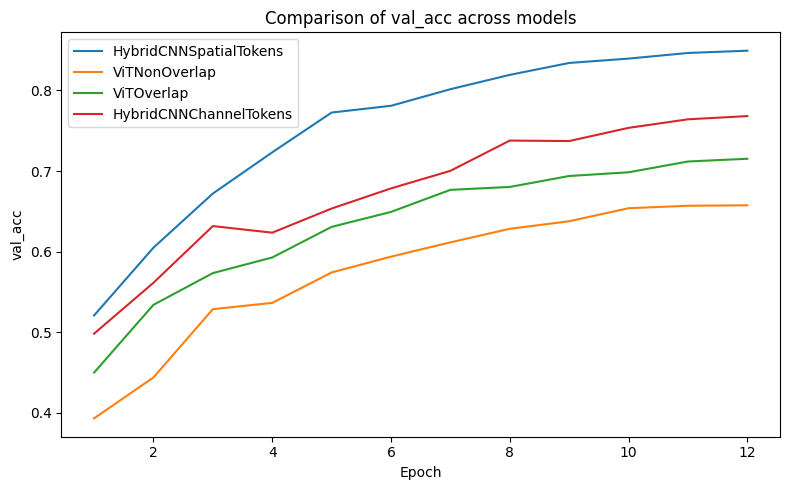

Saved figure -> outputs_part4/figures/10_compare_val_loss_curves.png


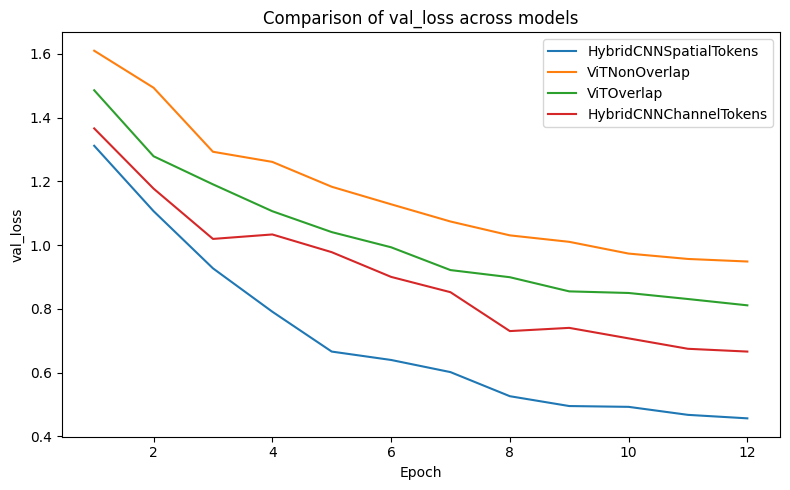

In [22]:
# Figure: so sánh đường validation accuracy và validation loss giữa các mô hình
plot_multi_model_curves(all_results, metric="val_acc", filename="09_compare_val_acc_curves.png")
plot_multi_model_curves(all_results, metric="val_loss", filename="10_compare_val_loss_curves.png")

## 10. Tự động sinh bảng nhận xét sơ bộ

Cell này không thay cho phần viết báo cáo cuối cùng, nhưng nó giúp bạn có khung nhận xét ban đầu để dựa vào khi viết document.

In [23]:
best_model_name = results_df.iloc[0]["model_name"]
fastest_model_name = results_df.sort_values("avg_epoch_time_sec").iloc[0]["model_name"]
smallest_model_name = results_df.sort_values("params").iloc[0]["model_name"]

print("Gợi ý nhận xét sơ bộ:")
print("- Mô hình có test accuracy tốt nhất:", best_model_name)
print("- Mô hình train nhanh nhất (avg epoch time thấp nhất):", fastest_model_name)
print("- Mô hình gọn nhất (ít params nhất):", smallest_model_name)
print()
print("Khi viết báo cáo, bạn nên đối chiếu 3 yếu tố:")
print("1. accuracy")
print("2. chi phí tính toán / thời gian train")
print("3. số token và cách embedding")

Gợi ý nhận xét sơ bộ:
- Mô hình có test accuracy tốt nhất: HybridCNNSpatialTokens
- Mô hình train nhanh nhất (avg epoch time thấp nhất): ViTNonOverlap
- Mô hình gọn nhất (ít params nhất): ViTNonOverlap

Khi viết báo cáo, bạn nên đối chiếu 3 yếu tố:
1. accuracy
2. chi phí tính toán / thời gian train
3. số token và cách embedding


## 11. Files đầu ra sau khi chạy notebook

Sau khi chạy xong, thư mục `outputs_part4/` sẽ có:
- `figures/`: toàn bộ chart, confusion matrix, sample predictions, patch visualization
- `checkpoints/`: trọng số tốt nhất của từng mô hình
- `tables/`: CSV cho lịch sử train và bảng tổng hợp kết quả

Bạn có thể dùng trực tiếp các file này để:
- đưa vào báo cáo PDF,
- chia sẻ với thành viên nhóm,
- tiếp tục viết phần nhận xét.

## 12. Gợi ý mở rộng nếu còn thời gian

Nếu muốn nâng chất lượng bài hơn nữa, có thể thử thêm:
- patch size khác nhau (4x4 vs 8x8),
- thêm mô hình row-token / column-token,
- thêm heatmap lỗi của từng class,
- thêm ablation nhỏ về số token hoặc embed dimension.

Tuy nhiên, bản notebook hiện tại đã **đủ chặt để đáp ứng tốt Part 4**.